<a href="https://colab.research.google.com/github/alheetiaabdullah/my-first-website/blob/main/beardata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'my-first-website'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 159 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 33.23 MiB | 17.79 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Found train images: 76
Found test images : 1
Batch tensor shape: torch.Size([16, 3, 256, 256])


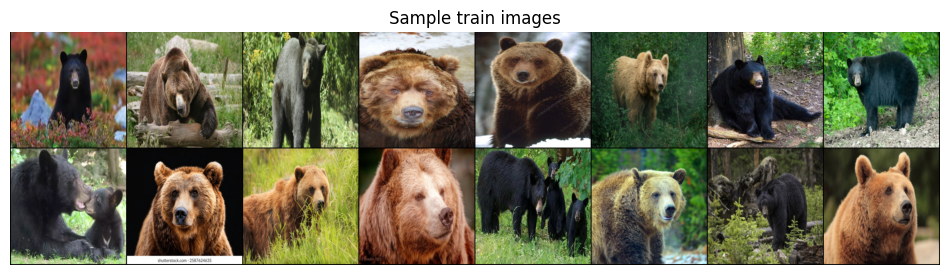

In [ ]:
# 1. Clone your repo fresh
!rm -rf my-first-website
!git clone https://github.com/alheetiaabdullah/my-first-website.git

# 2. Imports
import os, glob
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import torchvision

ImageFile.LOAD_TRUNCATED_IMAGES = True  # allow partially saved images

# 3. Paths
train_dir = "my-first-website/animals/train"
test_dir  = "my-first-website/animals/test"

# 4. Transform: resize + tensor
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# 5. Helper: collect images (all extensions)
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def list_images(folder):
    paths = []
    for ext in IMG_EXTS:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        paths.extend(glob.glob(os.path.join(folder, f"*/*{ext}")))  # one level deeper
    return sorted(paths)

# 6. Custom dataset (no need for class subfolders)
class ImagePathDataset(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label

# 7. Create datasets + loaders
train_files = list_images(train_dir)
test_files  = list_images(test_dir)

print("Found train images:", len(train_files))
print("Found test images :", len(test_files))

train_ds = ImagePathDataset(train_files, transform=transform)
test_ds  = ImagePathDataset(test_files,  transform=transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

# 8. Get a batch and show
images, _ = next(iter(train_loader))
print("Batch tensor shape:", images.shape)  # [B, 3, 256, 256]

grid = torchvision.utils.make_grid(images, nrow=8)
plt.figure(figsize=(12,4))
plt.imshow(grid.permute(1,2,0))  # CHW -> HWC
plt.axis("off")
plt.title("Sample train images")
plt.show()


Cloning into 'my-first-website'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 162 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 33.70 MiB | 20.13 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Found 76 train and 1 test images (total 77).


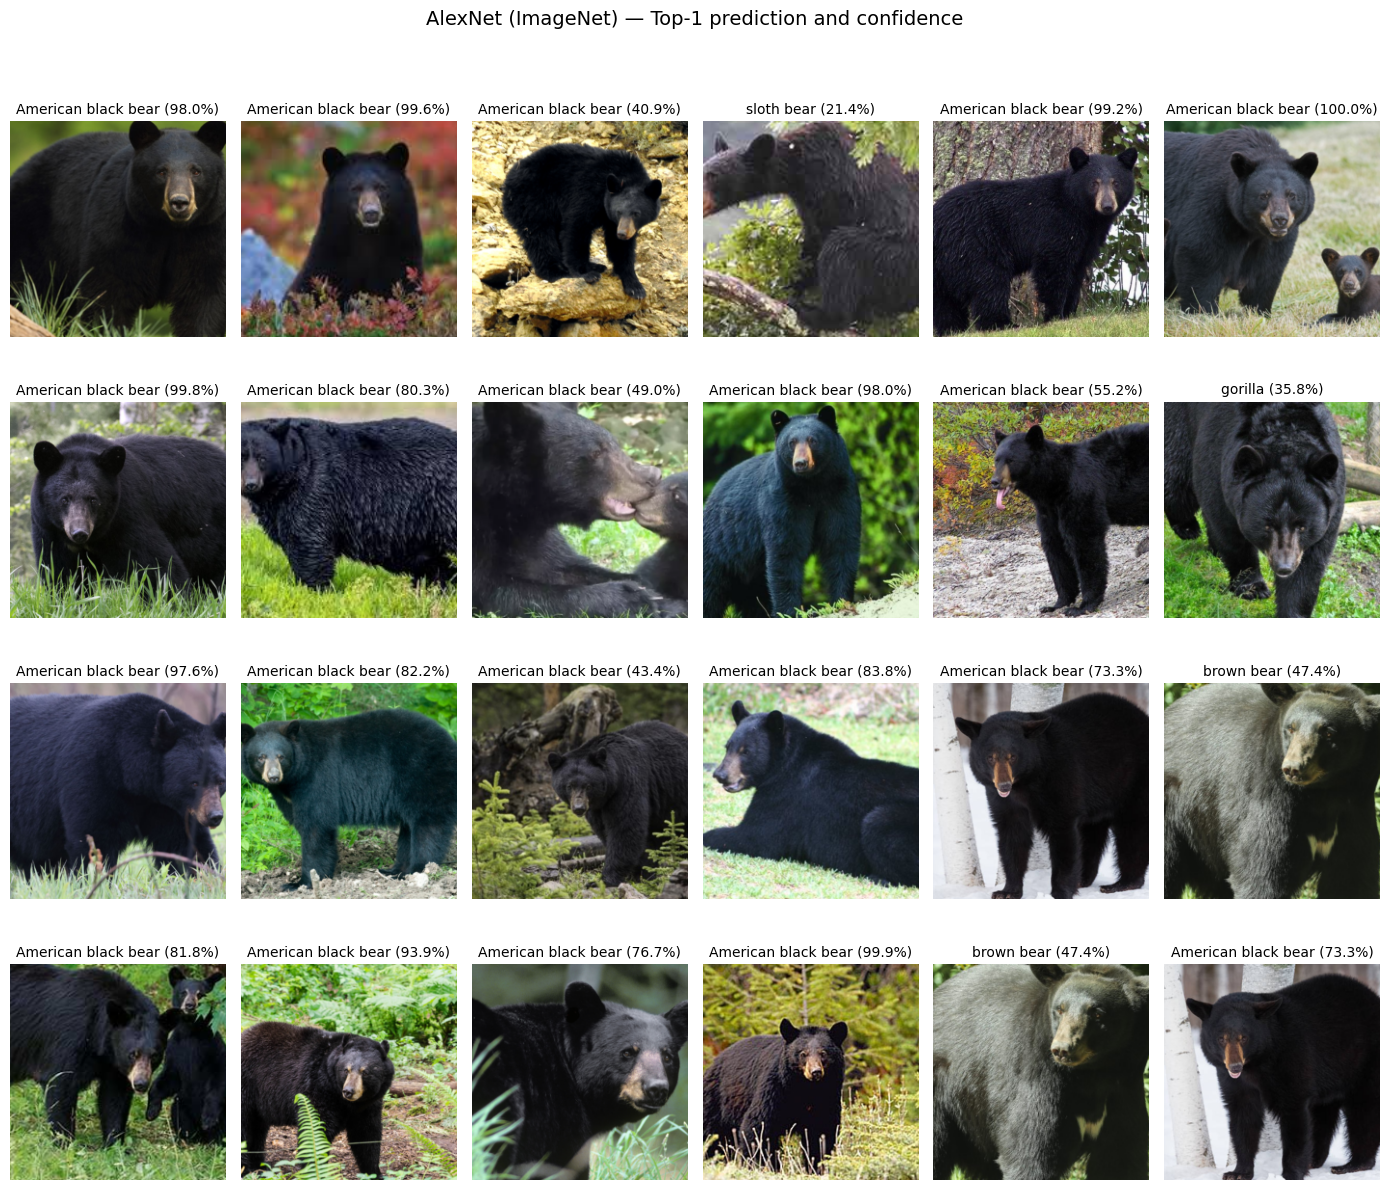


Total images scored: 77


,file,top1_label,top1_confidence,top1,top2,top3,top4,top5
0,grizzlybear31.jpg,brown bear,1.0000,brown bear (100.0%),hyena (0.0%),American black bear (0.0%),golden retriever (0.0%),red wolf (0.0%)
1,grizzlybear43.jpg,brown bear,1.0000,brown bear (100.0%),hyena (0.0%),bison (0.0%),Arabian camel (0.0%),ice bear (0.0%)
2,grizzlybear3.jpg,brown bear,1.0000,brown bear (100.0%),hog (0.0%),wild boar (0.0%),hyena (0.0%),African hunting dog (0.0%)
3,grizzlybear21.jpg,brown bear,0.9999,brown bear (100.0%),American black bear (0.0%),sloth bear (0.0%),ram (0.0%),hyena (0.0%)
4,grizzlybear24.jpeg,brown bear,0.9999,brown bear (100.0%),American black bear (0.0%),hyena (0.0%),ram (0.0%),basenji (0.0%)
5,grizzlybear7.png,brown bear,0.9999,brown bear (100.0%),hyena (0.0%),wild boar (0.0%),mongoose (0.0%),hog (0.0%)
6,grizzlybear49.jpg,brown bear,0.9998,brown bear (100.0%),hyena (0.0%),Norwich terrier (0.0%),chow (0.0%),wombat (0.0%)
7,grizzlybear20.jpg,brown bear,0.9998,brown bear (100.0%),American black bear (0.0%),Newfoundland (0.0%),sloth bear (0.0%),Irish water spaniel (0.0%)
8,black-bear-2 .jpg,American black bear,0.9997,American black bear (100.0%),brown bear (0.0%),sloth bear (0.0%),schipperke (0.0%),wild boar (0.0%)
9,grizzlybear26.webp,brown bear,0.9995,brown bear (99.9%),hyena (0.0%),red wolf (0.0%),American black bear (0.0%),timber wolf (0.0%)


In [3]:
# ===== 0) Fresh clone of your repo =====
!rm -rf my-first-website
!git clone https://github.com/alheetiaabdullah/my-first-website.git

# ===== 1) Imports =====
import os, glob, math, textwrap
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.utils.data._utils.collate import default_collate
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torchvision
from IPython.display import display
import requests
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ===== 2) Paths =====
TRAIN_DIR = "my-first-website/animals/train"
TEST_DIR  = "my-first-website/animals/test"

# ===== 3) Collect images (recursive + case-insensitive extensions) =====
IMG_EXTS = (".jpg",".jpeg",".png",".bmp",".webp",".JPG",".JPEG",".PNG",".BMP",".WEBP")

def list_images(folder):
    if not os.path.isdir(folder): return []
    files = []
    for ext in IMG_EXTS:
        files += glob.glob(os.path.join(folder, f"*{ext}"))
        files += glob.glob(os.path.join(folder, "**", f"*{ext}"), recursive=True)
    return sorted(set(files))

train_files = list_images(TRAIN_DIR)
test_files  = list_images(TEST_DIR)
all_files   = train_files + test_files
if not all_files:
    raise RuntimeError("No images found in animals/train or animals/test. Check paths and file extensions.")
print(f"Found {len(train_files)} train and {len(test_files)} test images (total {len(all_files)}).")

# ===== 4) Transforms =====
# AlexNet expects 224x224 RGB normalized to ImageNet stats.
input_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
# A second transform for display (same size but *not* normalized), kept as Tensor too.
display_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),  # keep as tensor so DataLoader can batch it
])

# ===== 5) Dataset returning tensors only (no PIL objects in the batch) =====
class ImagePathDataset(Dataset):
    def __init__(self, files, in_tf=None, out_tf=None):
        self.files = files
        self.in_tf = in_tf
        self.out_tf = out_tf
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        path = self.files[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            # If an image is unreadable, you can choose to skip it by raising or returning None
            raise RuntimeError(f"Failed to open image: {path}\n{e}")
        x_in  = self.in_tf(img)  if self.in_tf  else transforms.ToTensor()(img)   # [3,224,224] normalized
        x_out = self.out_tf(img) if self.out_tf else transforms.ToTensor()(img)   # [3,224,224] unnormalized
        return x_in, x_out, path

BATCH = 16
dataset = ImagePathDataset(all_files, in_tf=input_transform, out_tf=display_transform)
loader  = DataLoader(dataset, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

# ===== 6) Pretrained AlexNet (handle old/new torchvision) =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = None
try:
    weights = models.AlexNet_Weights.DEFAULT
    model = models.alexnet(weights=weights).to(device).eval()
    if hasattr(weights, "meta") and "categories" in weights.meta:
        classes = weights.meta["categories"]
except Exception:
    model = models.alexnet(pretrained=True).to(device).eval()

# Fallback for class names if meta is missing or network blocked
if classes is None:
    try:
        txt = requests.get("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt", timeout=10).text
        classes = txt.strip().splitlines()
    except Exception:
        classes = [f"class_{i}" for i in range(1000)]

# ===== 7) Inference helper =====
def topk_from_logits(logits, k=5):
    probs = F.softmax(logits, dim=1)
    confs, inds = probs.topk(k, dim=1)
    return confs.detach().cpu().numpy(), inds.detach().cpu().numpy()

# ===== 8) Run inference =====
all_rows = []
viz_imgs  = []   # list of tensors (unnormalized) for plotting
viz_titles= []   # matching titles

model.eval()
with torch.inference_mode():
    for batch_in, batch_disp, batch_paths in loader:
        batch_in = batch_in.to(device)
        logits = model(batch_in)
        confs, inds = topk_from_logits(logits, k=5)  # shapes [B,5]

        for i, path in enumerate(batch_paths):
            fname = os.path.basename(path)
            top5 = [(classes[int(inds[i,j])], float(confs[i,j])) for j in range(5)]
            top1_label, top1_conf = top5[0]

            row = {"file": fname, "top1_label": top1_label, "top1_confidence": round(top1_conf,4)}
            for j, (lbl, cf) in enumerate(top5, start=1):
                row[f"top{j}"] = f"{lbl} ({cf*100:.1f}%)"
            all_rows.append(row)

        # keep up to 24 images for a nice gallery
        keep = min(batch_disp.shape[0], max(0, 24 - len(viz_imgs)))
        if keep > 0:
            viz_imgs.extend(batch_disp[:keep])  # tensors in [0,1]
            viz_titles.extend([f"{classes[int(inds[i,0])]} ({confs[i,0]*100:.1f}%)" for i in range(keep)])

# ===== 9) Pretty grid (per-image titles) =====
def show_grid(img_tensors, titles, ncols=6):
    n = len(img_tensors)
    if n == 0:
        print("No images to display.")
        return
    ncols = max(1, ncols)
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(14, max(4, nrows*3)))
    for i, (img_t, title) in enumerate(zip(img_tensors, titles), start=1):
        plt.subplot(nrows, ncols, i)
        # img_t is [3,H,W] in [0,1]
        npimg = img_t.permute(1,2,0).numpy()
        npimg = np.clip(npimg, 0, 1)
        plt.imshow(npimg)
        plt.axis("off")
        plt.title("\n".join(textwrap.wrap(title, width=28)), fontsize=10)
    plt.suptitle("AlexNet (ImageNet) — Top-1 prediction and confidence", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

show_grid(viz_imgs, viz_titles, ncols=6)

# ===== 10) Results table (top-5) =====
df = pd.DataFrame(all_rows).sort_values("top1_confidence", ascending=False).reset_index(drop=True)
pd.set_option("display.max_colwidth", 120)
print(f"\nTotal images scored: {len(df)}")
display(df[["file","top1_label","top1_confidence","top1","top2","top3","top4","top5"]].head(30))
